In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("college.csv")

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

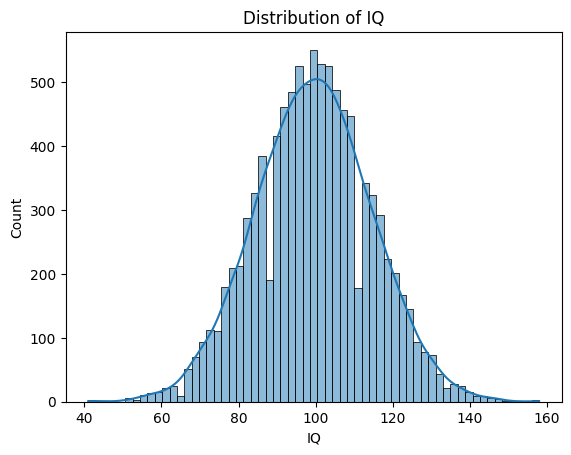

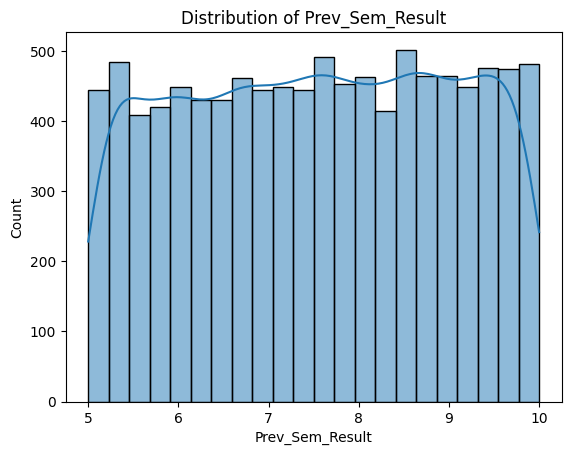

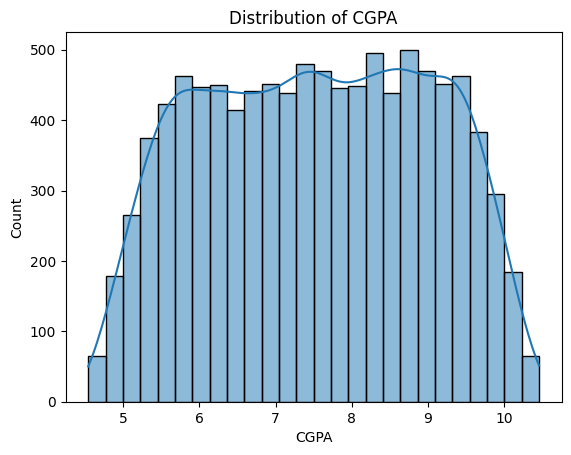

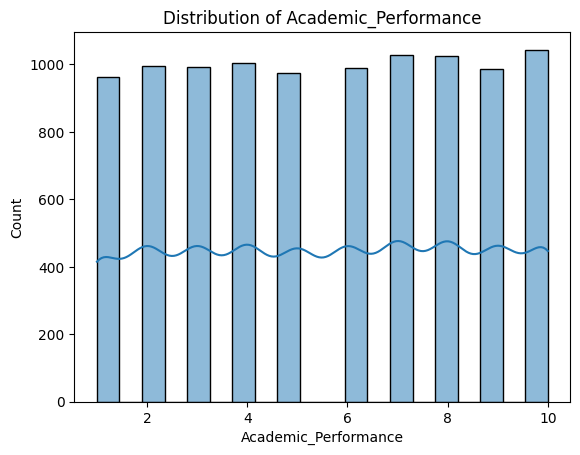

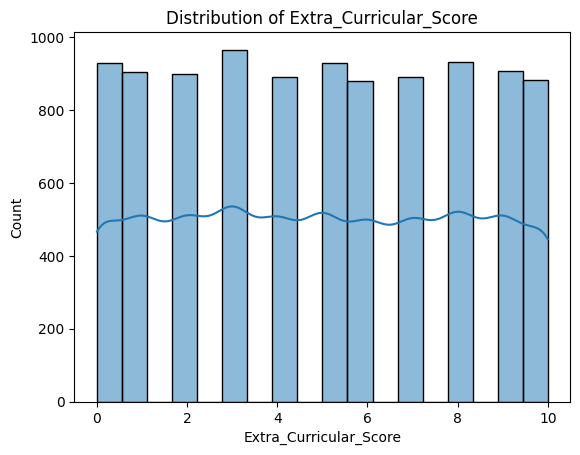

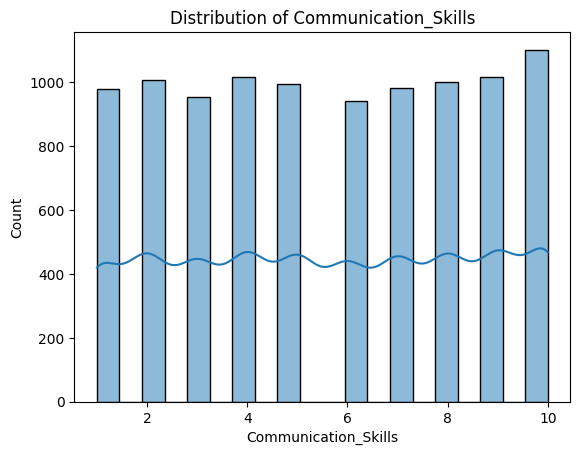

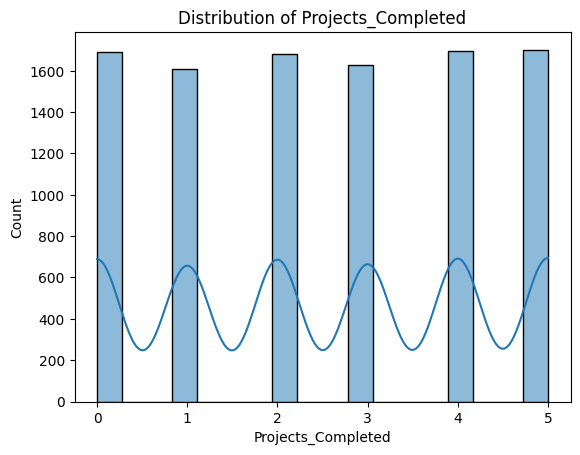

In [3]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

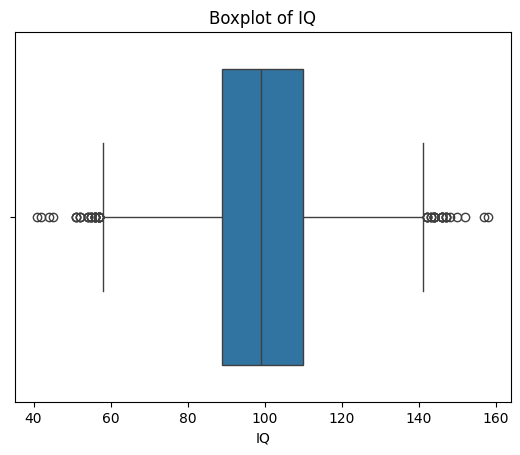

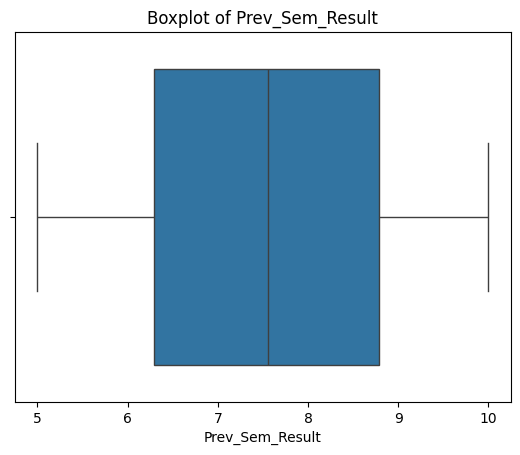

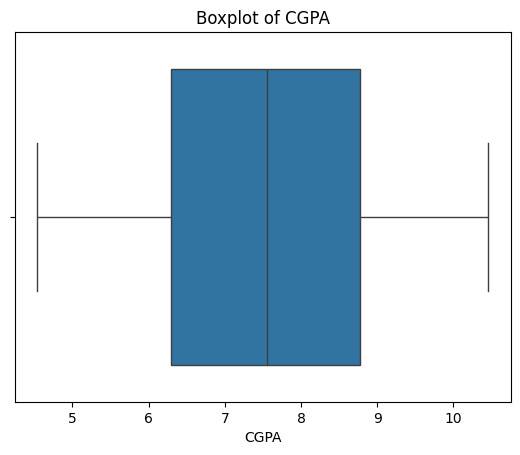

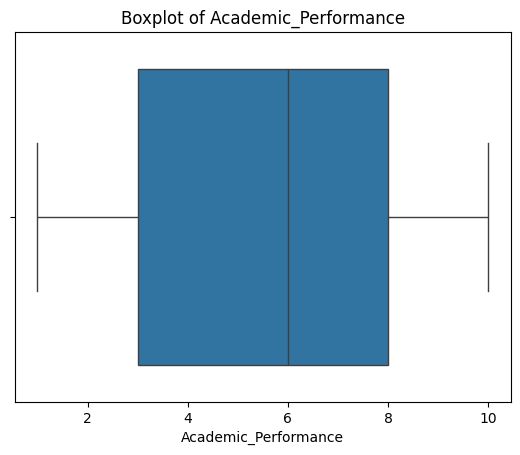

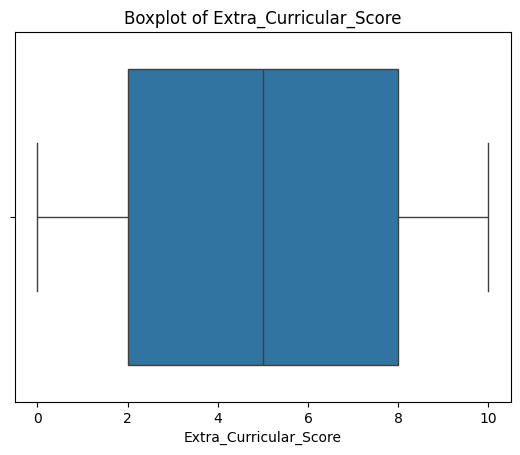

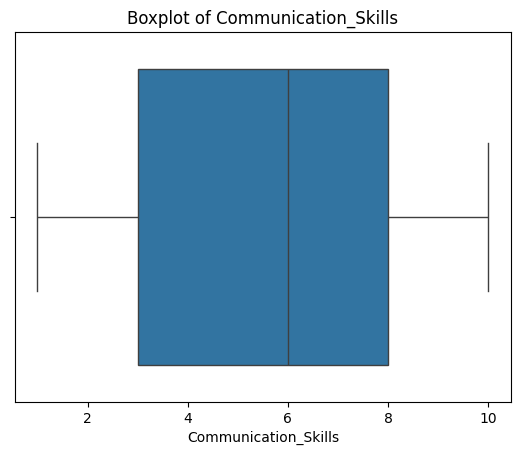

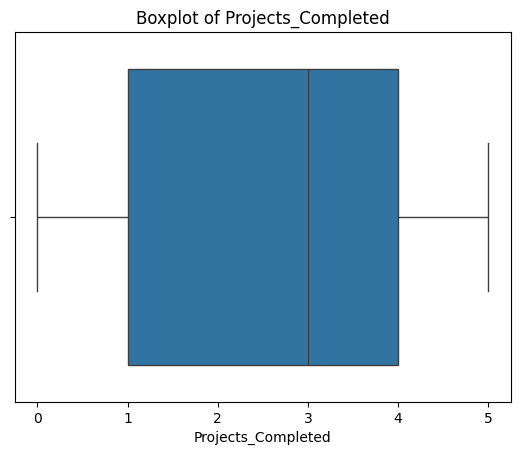

In [4]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

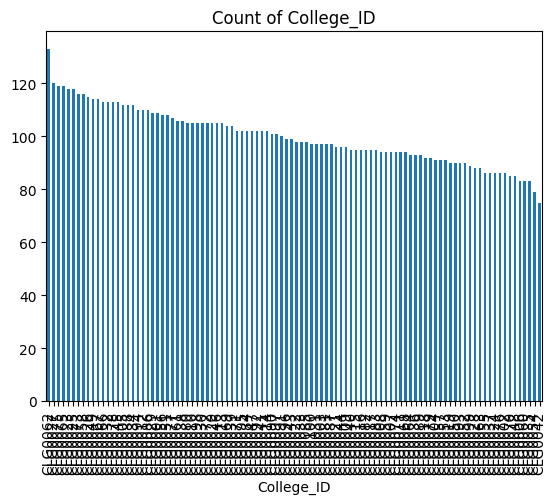

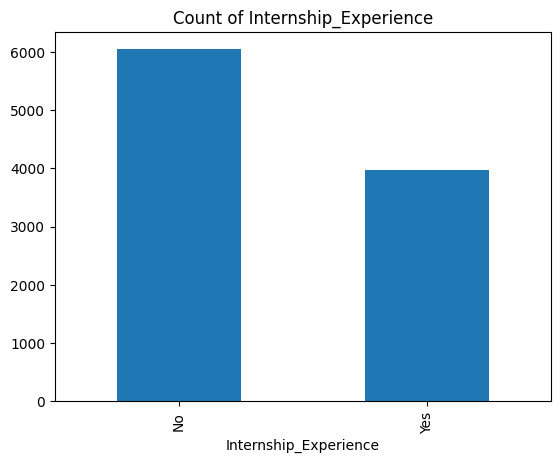

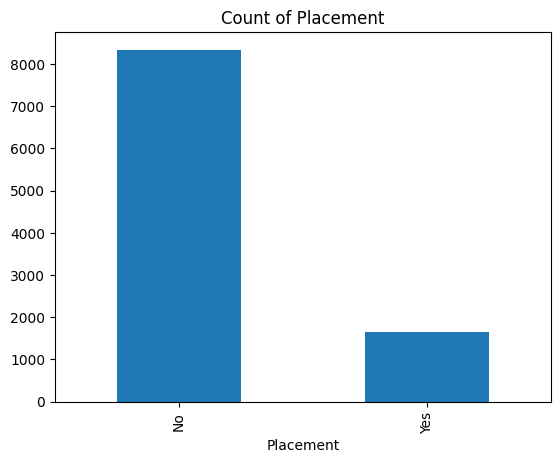

In [5]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count of {col}")
    plt.show()

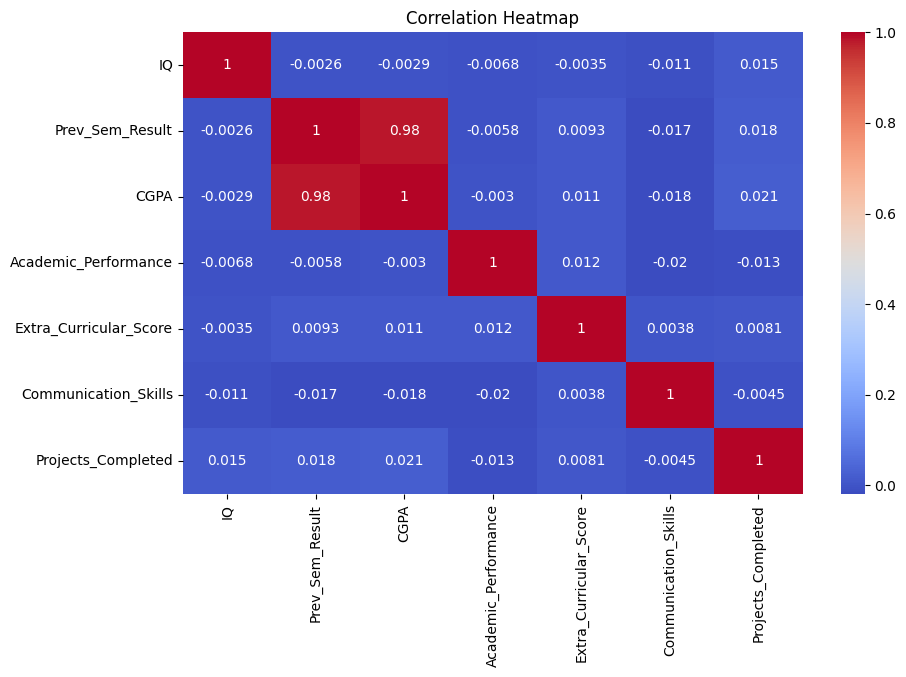

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

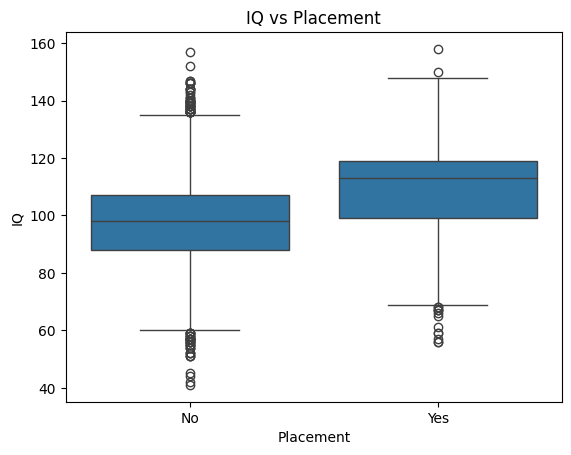

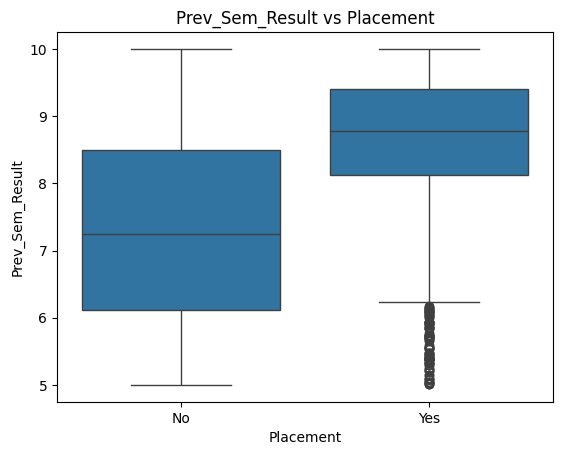

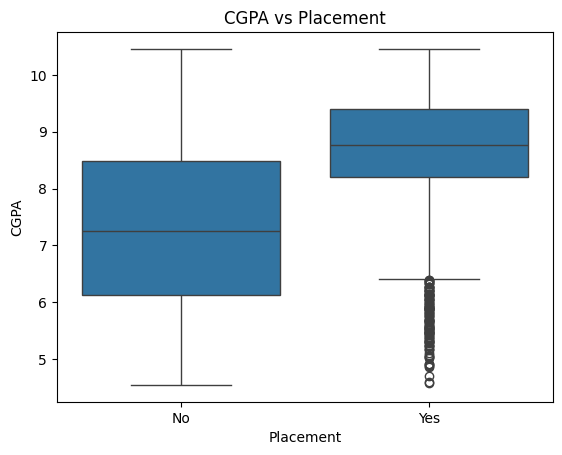

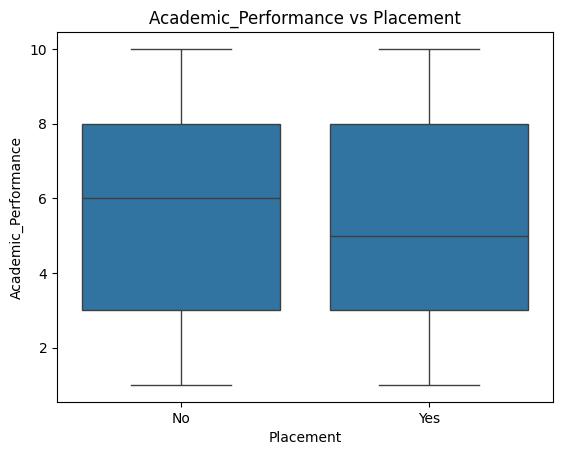

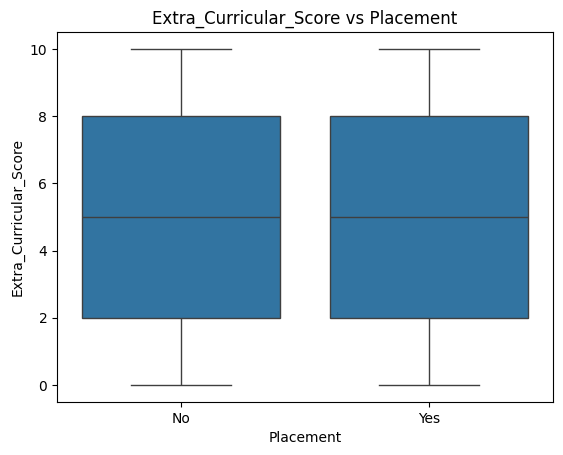

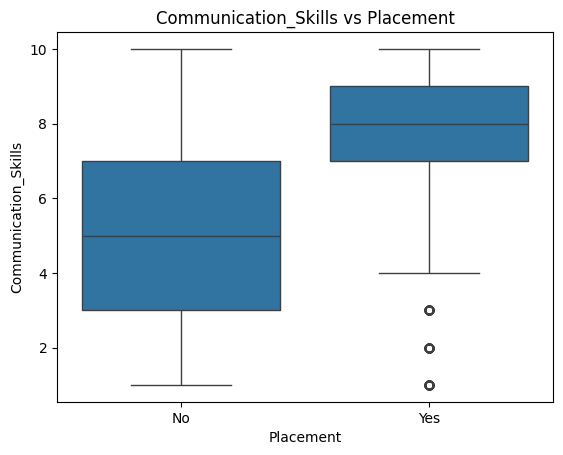

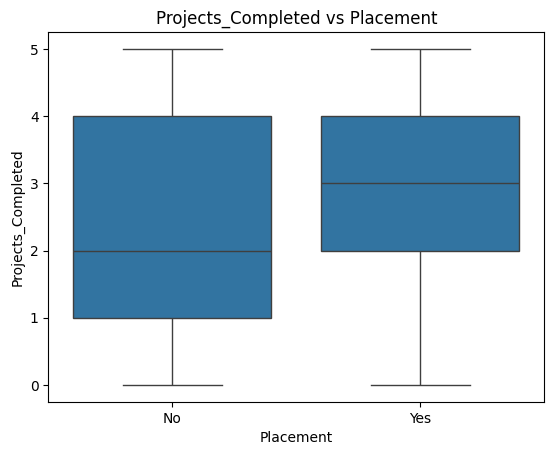

In [7]:
for col in num_cols:
    if col != 'Placement':
        plt.figure()
        sns.boxplot(x=df['Placement'], y=df[col])
        plt.title(f"{col} vs Placement")
        plt.show()

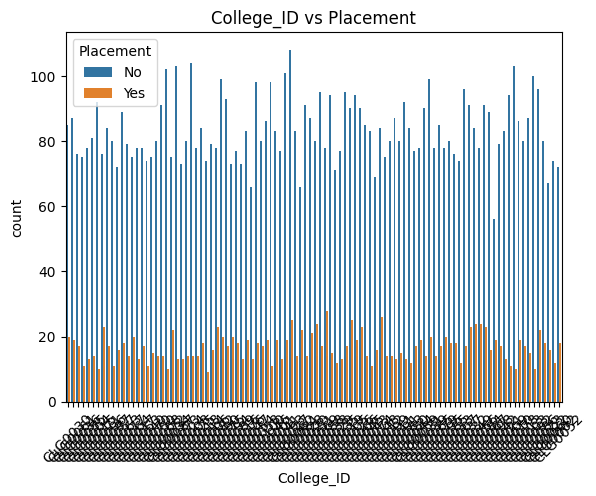

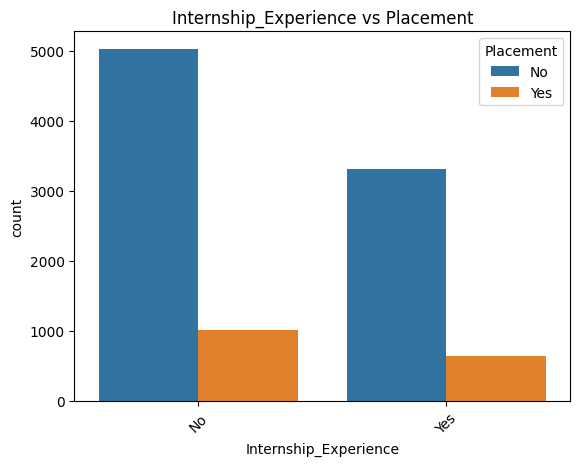

In [8]:
for col in cat_cols:
    if col != 'Placement':
        plt.figure()
        sns.countplot(x=col, hue='Placement', data=df)
        plt.title(f"{col} vs Placement")
        plt.xticks(rotation=45)
        plt.show()

In [9]:
df['Placement'] = df['Placement'].map({'No':0, 'Yes':1})

In [10]:
df = df.drop(columns=['College_ID'])

In [17]:
from sklearn.model_selection import train_test_split





In [22]:
from sklearn.model_selection import train_test_split
feature_train,feature_test,target_train,target_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
model=DecisionTreeClassifier(criterion="gini",random_state=42)
df = df.replace({'Yes': 1, 'No': 0})
X = df.drop('Placement', axis=1)
y = df['Placement']
model.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
from sklearn.metrics import accuracy_score
Y_pred=model.predict(feature_test)

In [25]:
print("Accuracy:",accuracy_score(target_test,Y_pred)*100)

Accuracy: 100.0


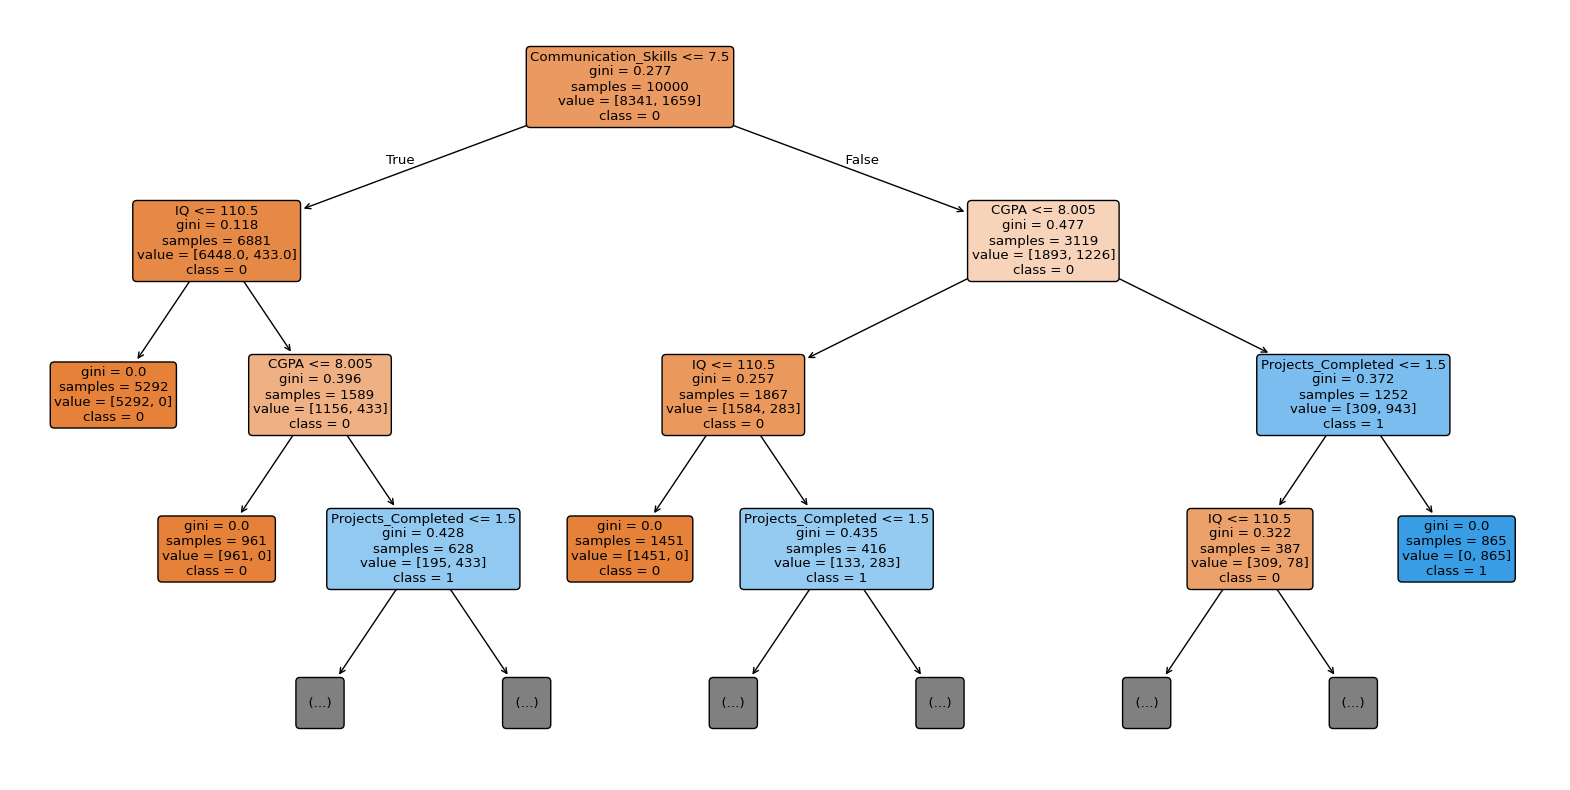

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=X.columns,
          class_names=[str(i) for i in model.classes_],
          filled=True,
          rounded=True,
          max_depth=3)
plt.show()